In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from few.waveform import GenerateEMRIWaveform
from few.utils.constants import MTSUN_SI
from few.utils.utility import get_p_at_t
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.fdutils import GetFDWaveformFromFD, GetFDWaveformFromTD
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux, KerrEccEqFlux_nex

from scipy.interpolate import CubicSpline
from few import get_file_manager

# produce sensitivity function
traj_module = EMRIInspiral(func=KerrEccEqFlux_nex, use_gpu=True)

# import ASD
data = np.loadtxt(get_file_manager().get_file("LPA.txt"), skiprows=1)
data[:, 1] = data[:, 1] ** 2
# define PSD function
get_sensitivity = CubicSpline(*data.T)

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 12,
})

from cycler import cycler

plt.rcParams['axes.prop_cycle'] = cycler(color=[
    "#373E8E",  # black
    "#b4af1f",  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
])

from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux_nex",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

td_gen_few = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

In [12]:
# define the injection parameters
n=2

m1 = 1e6  # central object mass (solar masses)
a =  1-10**(-n)    # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform
m2 = 10.0  # secondary object mass (solar masses)
p0 = 6.0  # initial dimensionless semi-latus rectum 
e0 = 0.1  # eccentricity

x0 = 1.0         # initial cos(inclination) - will be ignored in Schwarzschild waveform
qK = np.pi / 3   # polar spin angle
phiK = np.pi / 3 # azimuthal viewing angle
qS = np.pi / 3   # polar sky angle
phiS = np.pi / 3 # azimuthal viewing angle
dist = 1.0       # luminosity distance (Gpc)

# initial phases
Phi_phi0 = np.pi / 3
Phi_theta0 = 0.0
Phi_r0 = np.pi / 3

Tobs =   1/365/24  # observation time (years), if the inspiral is shorter, the it will be zero padded
dt = 1.0    # time interval (seconds)
mode_selection_threshold = 1e-5  # relative threshold for mode inclusion: only modes making a relative contribution to
            # the total power above this threshold will be included in the waveform.



waveform_kwargs = {
    "T": Tobs,
    "dt": dt,
    "mode_selection_threshold": mode_selection_threshold,
}

# get the initial p0 required for an inspiral of length Tobs, given the fixed values of the other parameters

p0 = get_p_at_t(
    traj_module,
    Tobs * 0.999,
    [m1, m2, a, e0, 1.0],       # list of trajectory arguments, with p removed
    index_of_p=3,               # index where to insert the new p values in the above traj_args list when traj_module is called 
    index_of_a=2,               # index of a in the list of trajectory arguments when calling traj_module
    index_of_e=4,               # etc...
    index_of_x=5,
    traj_kwargs={},
    xtol=2e-12,                 # absolute tolerance for the brentq root finder
    rtol=8.881784197001252e-16, # relative tolerance for the brentq root finder
    bounds=None,
)
print("New p0: ", p0)

p0=1.5498094645542098

emri_injection_params = [
    m1,
    m2,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
]

New p0:  1.5498094645542098


In [13]:
start = time.time()
data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) # Returns 2 arrays containing the plus and cross polarizations
end = time.time()
print("Time taken to generate the NEX TD signal: ", end - start, "seconds")


start = time.time()
data_channels_td_few = td_gen_few(*emri_injection_params, **waveform_kwargs) 
end = time.time()
print("Time taken to generate the FEW TD signal: ", end - start, "seconds")



Time taken to generate the NEX TD signal:  0.13074326515197754 seconds
Time taken to generate the FEW TD signal:  0.175459623336792 seconds


In [14]:
time_array = np.arange(0, len(data_channels_td[0])) * dt
time_array_few = np.arange(0, len(data_channels_td_few[0])) * dt

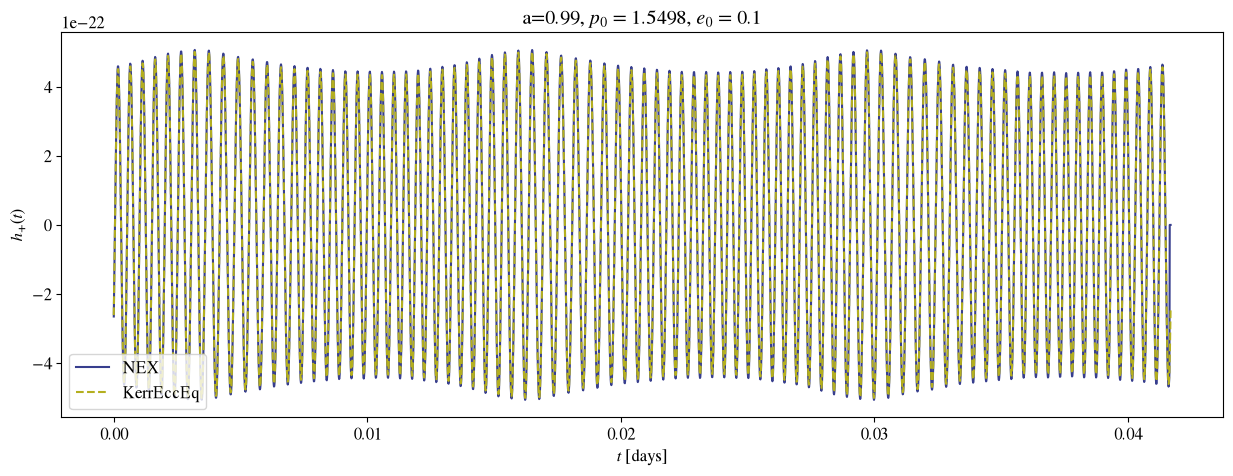

In [15]:

plt.figure(figsize=(15,5))

plt.plot(time_array/60/60/24, data_channels_td[0].real, label="NEX")
plt.plot(time_array_few/60/60/24, data_channels_td_few[0].real,"--", label="KerrEccEq")

plt.ylabel(r"$h_{+}(t)$")
plt.xlabel(r"$t$ [days]")

tag=239.5

#plt.xlim(tag,tag+0.02)
plt.legend(loc = 'lower left')
plt.title(rf"a={a}, $p_0$ = {round(p0,4)}, $e_0$ = {e0}")

plt.savefig(f"Compare_WF_a={a}_e0={e0}_p0={p0}_day_long_insp.png", dpi=300, bbox_inches="tight")

Text(0.5, 0.98, 'a=0.999, $p_0$ = 4, $e_0$ = 0.2')

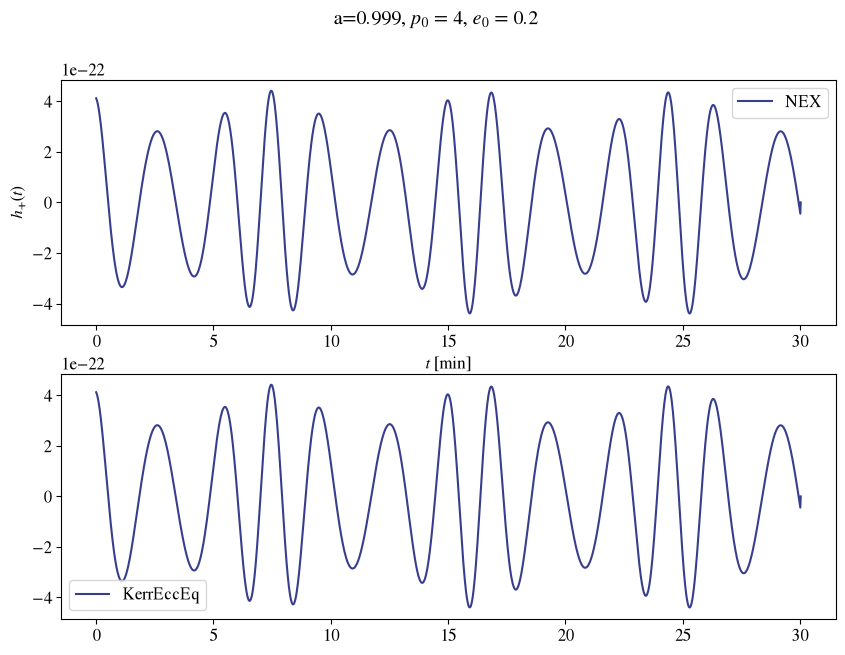

In [16]:
fig, axs = plt.subplots(2,1,figsize = (10,7))

time_array = np.arange(0, len(data_channels_td[0])) * dt
axs[0].plot(time_array/60, data_channels_td[0].real, label="NEX")
axs[1].plot(time_array/60, data_channels_td_few[0].real,"-", label="KerrEccEq")

axs[0].set_ylabel(r"$h_{+}(t)$")
axs[0].set_xlabel(r"$t$ [min]")

#plt.xlim(0,30)
axs[0].legend()
axs[1].legend()
plt.suptitle(rf"a={a}, $p_0$ = {round(p0,4)}, $e_0$ = {e0}")

In [ ]:
plt.figure()

time_increments = [1 , 60 , (3600), (24*3600), 24*2600*365 ]    
time_names = ["seconds","minutes","hours","days", "years"]
i=2

time_array_few = np.arange(0, len(data_channels_td_few[0])) * dt
plt.plot(time_array_few/time_increments[i], data_channels_td_few[0].real, label="TD waveform")

time_array = np.arange(0, len(data_channels_td[0])) * dt
plt.plot(time_array/time_increments[i], data_channels_td[0].real, "--",label="TD waveform")



plt.ylabel(r"$h_{+}(t)$")
plt.xlabel(rf"$t$ ({time_names[i]})")

plt.xlim(0,1)

In [ ]:
3600*24/60

In [ ]:
60*24

In [52]:
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux_nex",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

def wf_gen(n,e0,T,p0=None,a=None):


        # define the injection parameters
    m1 = 1e6  # central object mass (solar masses)
    if a == None:
        a = 1-10**(-n)    # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform
    else:
        a=a
        print(a)
    m2 = 10.0  
    p0 = p0  
    e0 = e0  

    x0 = 1.0         # initial cos(inclination) - will be ignored in Schwarzschild waveform
    qK = np.pi / 3   # polar spin angle
    phiK = np.pi / 3 # azimuthal viewing angle
    qS = np.pi / 3   # polar sky angle
    phiS = np.pi / 3 # azimuthal viewing angle
    dist = 1.0       # luminosity distance (Gpc)

    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_theta0 = 0.0
    Phi_r0 = np.pi / 3

    Tobs = T   
    if T>0.5:         
        dt = 1    
    elif T<1/365:
        dt=0.1
    else:
        dt=1   


    mode_selection_threshold = 1e-5




    waveform_kwargs = {
        "T": Tobs,
        "dt": dt,
        "mode_selection_threshold": mode_selection_threshold,
    }

   
    if p0 is None:
        p0 = get_p_at_t(
            traj_module,
            Tobs*0.99999,
            [m1, m2, a, e0, 1.0],       
            index_of_p=3,               
            index_of_a=2,               
            index_of_e=4,               
            index_of_x=5,
            traj_kwargs={},
            xtol=2e-12,                 
            rtol=8.881784197001252e-16, 
            bounds=None,
        )
        print("New p0: ", p0)



    emri_injection_params = [
        m1,
        m2,
        a,
        p0,
        e0,
        x0,
        dist,
        qS,
        phiS,
        qK,
        phiK,
        Phi_phi0,
        Phi_theta0,
        Phi_r0,
    ]


    data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) 
    time_array = np.arange(0, len(data_channels_td[0])) * dt

    return [time_array, data_channels_td,p0]

In [ ]:
e_vals = [00,0.05,0.1,0.15,0.2,0.25,0.3,0.35]
h=24*15     #numbver of hours
time = (1/365)*(h/24)
n=8

ts, wfs = [],[]

for e_val in e_vals:
    t1,wf1 = wf_gen(n,e_val,time)
    ts.append(t1)
    wfs.append(wf1)

New p0:  1.807384017782439
New p0:  1.8444657609188344
New p0:  1.8636592831469379
New p0:  1.898090626101635
New p0:  1.9260545542050043
New p0:  1.9472776787058894
New p0:  1.963524718578063
New p0:  1.9763918655359813
New p0:  1.986647567505543


In [54]:


e_vals = np.array([0.00, 0.025,0.05 , 0.10 , 0.15,0.2,0.25])

nj = len(e_vals)
E = np.empty((nj, nj))

for i in range(nj - 1):
    E[i] = np.linspace(e_vals[i], e_vals[i + 1], nj,endpoint=False)

#E[-1] = e_vals[-1]  # Last row is all 0.35
E=E[:-1]

h=24*4    #numbver of hours
time = (1/365)*(h/24)
n=8

ts, wfs,p0s = np.empty_like(E,dtype=object), np.empty_like(E,dtype=object),np.empty_like(E,dtype=object)
a=0.9999982217

for i in range(E.shape[0]):
    for j in range(E.shape[1]):
        res = wf_gen(n,E[i, j],time,a=a)
        ts[i, j] , wfs[i,j], p0s[i,j] = res[0] ,res[1], res[2]
print(E)

0.9999982217
New p0:  1.1520929724365938
0.9999982217
New p0:  1.1559881085553638
0.9999982217
New p0:  1.1591381923048218
0.9999982217
New p0:  1.161907009839011
0.9999982217
New p0:  1.1645334425932794
0.9999982217
New p0:  1.1671581494007557
0.9999982217
New p0:  1.1698524067276854
0.9999982217
New p0:  1.1726419110929367
0.9999982217
New p0:  1.175524531574328
0.9999982217
New p0:  1.1784862672656524
0.9999982217
New p0:  1.1815114526121602
0.9999982217
New p0:  1.1845858255875403
0.9999982217
New p0:  1.187697269847738
0.9999982217
New p0:  1.1908329174767824
0.9999982217
New p0:  1.1939787634182353
0.9999982217
New p0:  1.200247008085522
0.9999982217
New p0:  1.206423156041628
0.9999982217
New p0:  1.212478336369319
0.9999982217
New p0:  1.218421730259044
0.9999982217
New p0:  1.224281865852791
0.9999982217
New p0:  1.2300805798668524
0.9999982217
New p0:  1.235830966871659
0.9999982217
New p0:  1.2415408151884484
0.9999982217
New p0:  1.2472151728415026
0.9999982217
New p0:  1.2

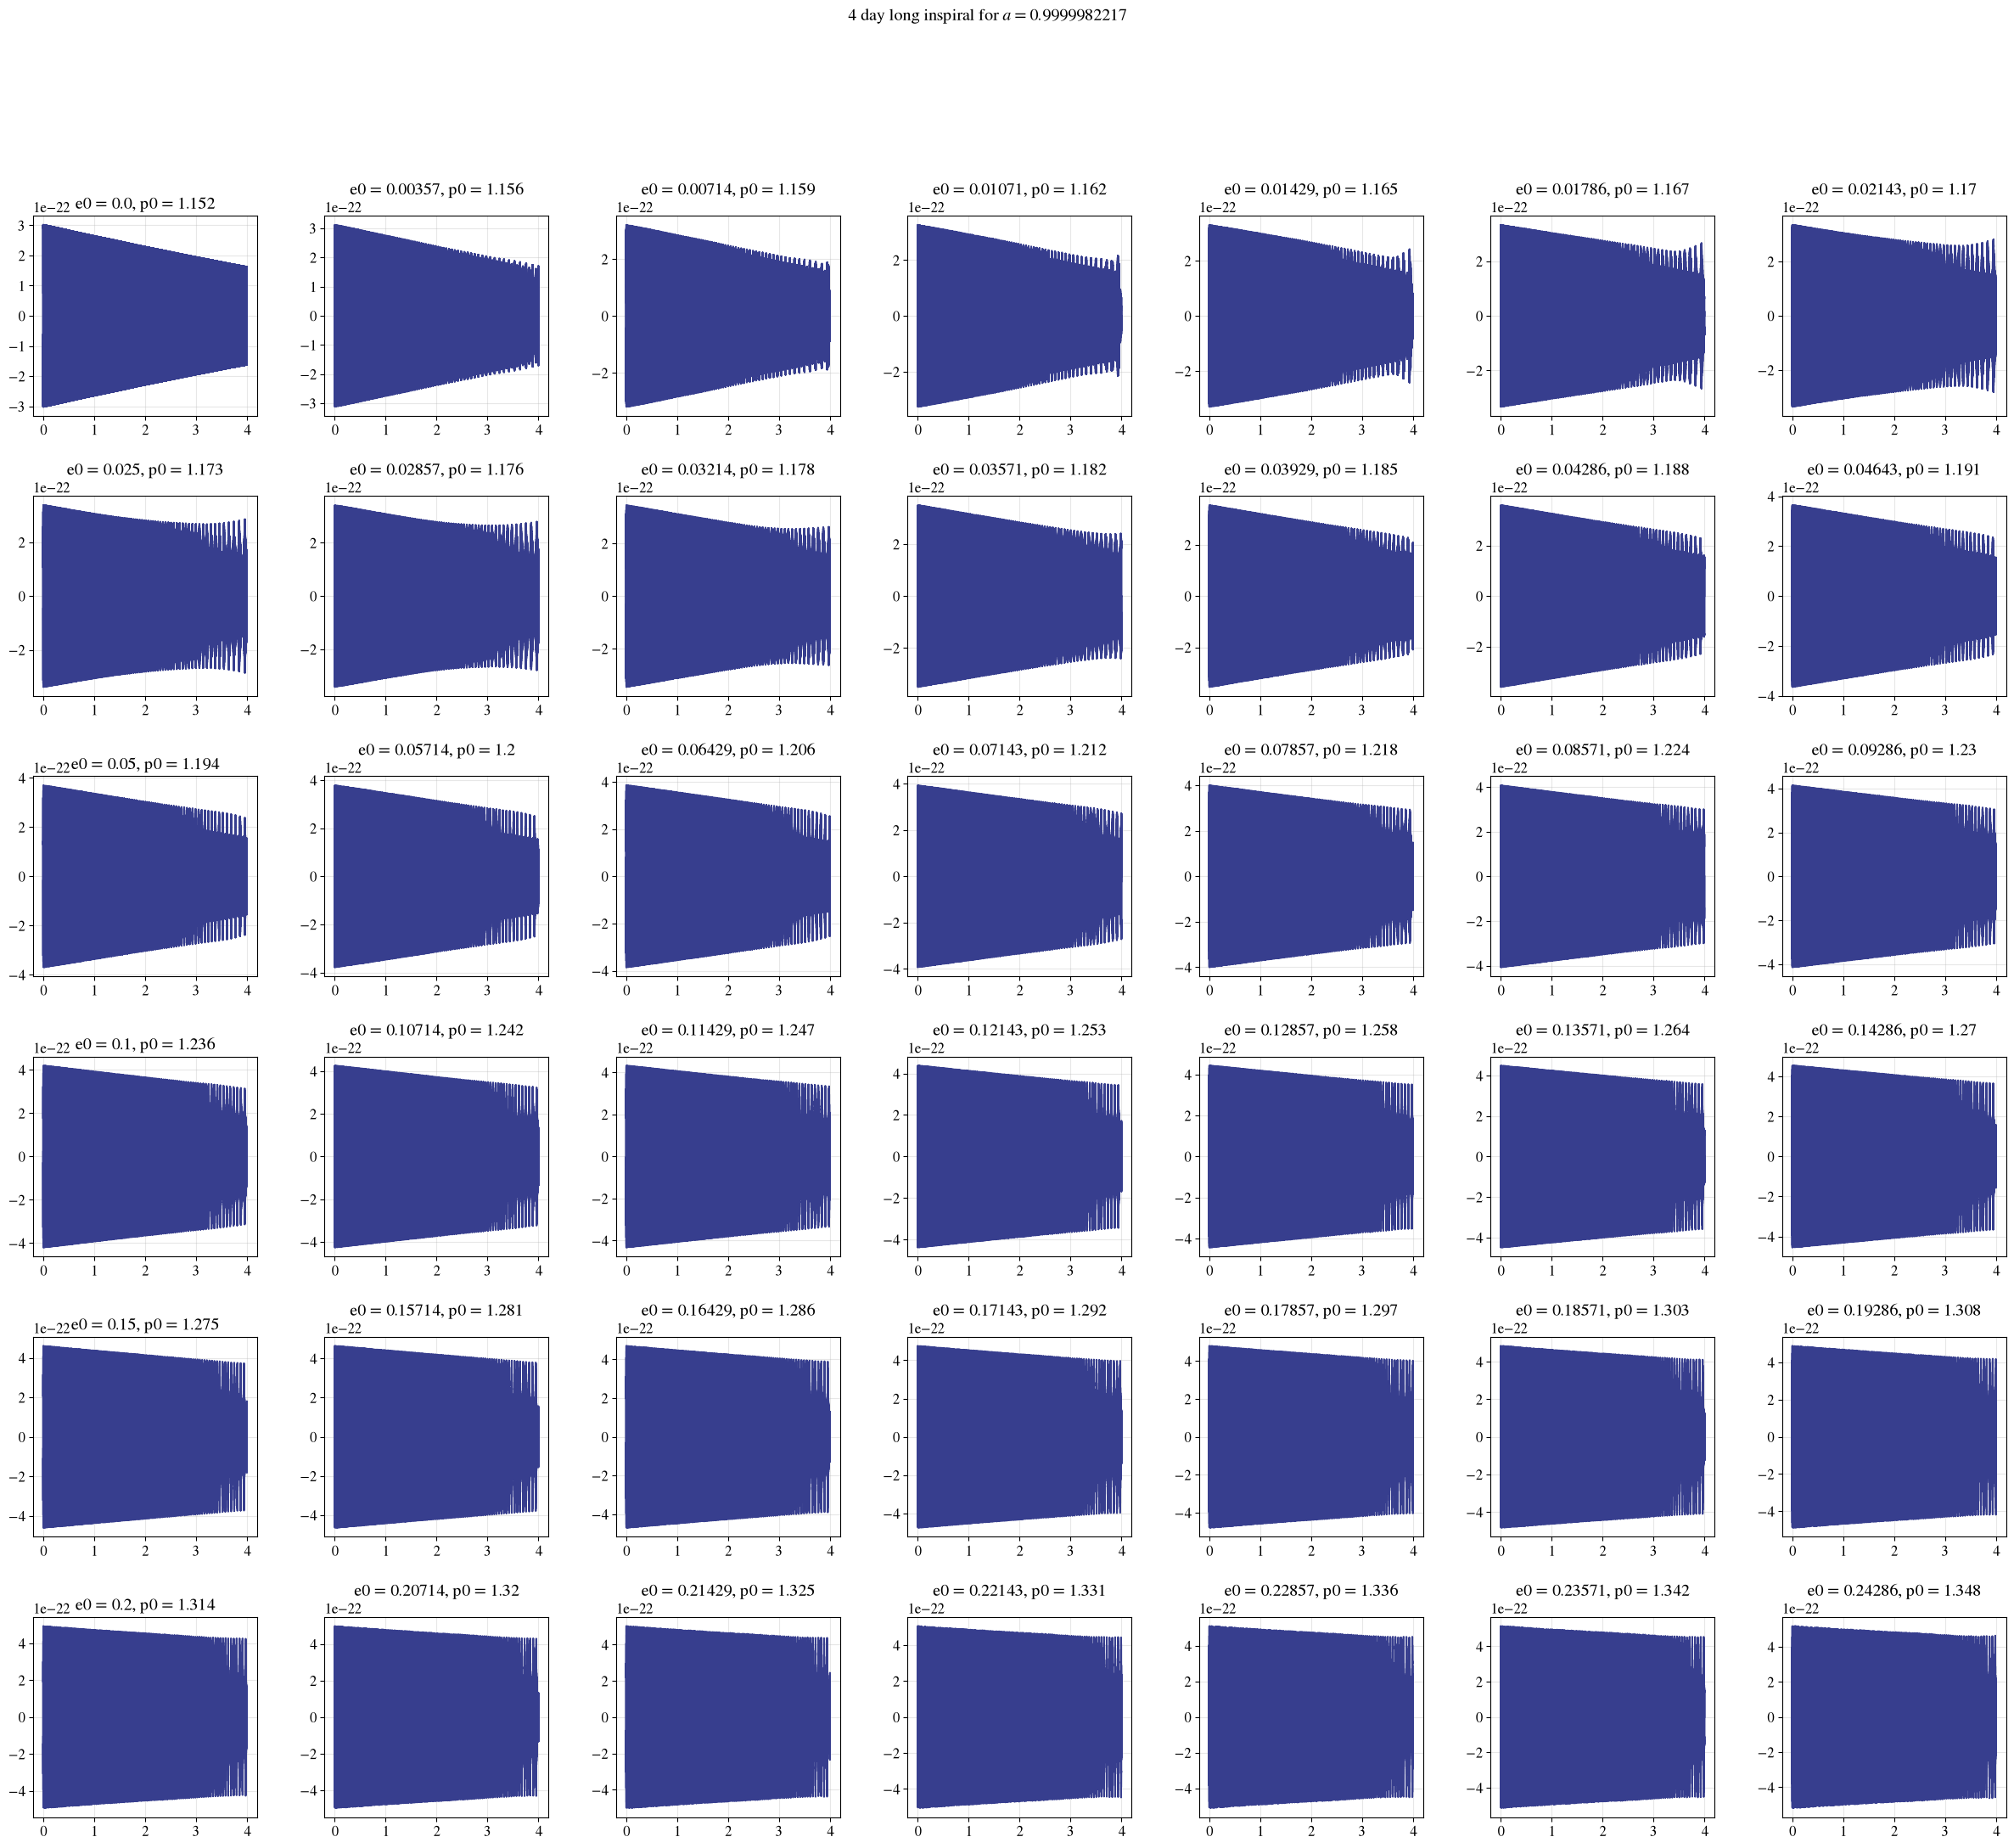

In [ ]:
time_increments =   [1 ,       60 ,     (3600), (24*3600),24*2600*365 ]    
time_names =        ["seconds","minutes","hours","days", "years"]
i=2

fig,axs = plt.subplots(len(e_vals)-1,len(e_vals),figsize = (30,3.5*(len(e_vals))))

tdiv = time_increments[i]

for i in range(len(e_vals)-1):
    for j in range(len(e_vals)):

        axs[i, j].plot(ts[i,j]/time_increments[3], wfs[i, j][0])
        axs[i, j].grid(alpha=0.3)
        axs[i,j].set_title(f"e0 = {round(E[i,j],5)}, p0 = {round(p0s[i,j],3)}")
    #ax.set_xlim(364.8,364.9)
    #ax.set_ylim(364.8,364.9

#plt.suptitle(rf"15 day long inspiral for $a=1-10^{{-{n}}}$")
plt.suptitle(rf"4 day long inspiral for $a={a}$")

plt.subplots_adjust(hspace=0.4)
plt.subplots_adjust(wspace=0.3)


fig.savefig(f"EGRID3_WF_a_on_grid_T=4day.png", dpi=300, bbox_inches="tight")

In [48]:
n_vals = [4,5,6,7,8,9,10,11,12]
h=0.3     #numbver of hours
time = (1/365)*(h/24)
e0=0.4

ts, wfs = [],[]

for n_val in n_vals:
    t1,wf1 = wf_gen(n_val,e0,time)
    ts.append(t1)
    wfs.append(wf1)

New p0:  1.4848168852127257
New p0:  1.4593413463389657
New p0:  1.4512958811462269
New p0:  1.4487561442686319
New p0:  1.4479530783224457
New p0:  1.4476989484161233
New p0:  1.447618743720426
New p0:  1.4475932746310851
New p0:  1.447585280732901


Text(0, 0.5, '$h_{+}(t)$')

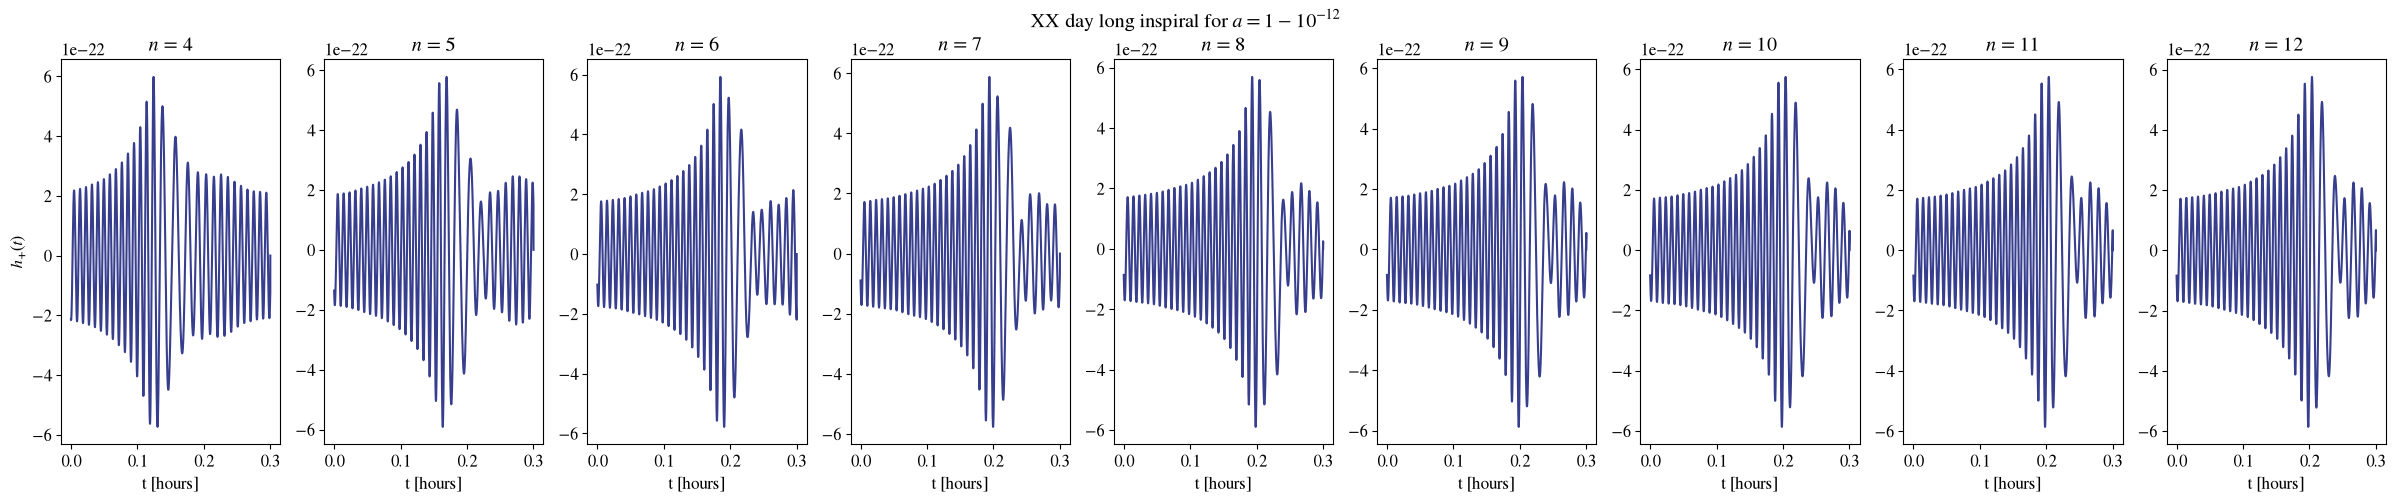

In [49]:
time_increments =   [1 ,       60 ,     (3600), (24*3600),24*2600*365 ]    
time_names =        ["seconds","minutes","hours","days", "years"]
i=2

fig,axs = plt.subplots(1,len(e_vals),figsize = (30,5))

tdiv = time_increments[i]

for ax,wf,tt,n_val in zip(axs,wfs,ts,n_vals):
    ax.set_xlabel(f"t [{time_names[i]}]")
    ax.set_title(f"$n$ = {n_val}")
    ax.plot(tt/(tdiv),wf[0])   
    
    #ax.set_xlim(364.8,364.9)
    #ax.set_ylim(364.8,364.9

plt.suptitle(rf"XX day long inspiral for $a=1-10^{{-{n}}}$")
axs[0].set_ylabel(r"$h_{+}(t)$")


#fig.savefig(f"WF_n=9_T=30day.png", dpi=300, bbox_inches="tight")

In [16]:
rhs_nex = KerrEccEqFlux_nex()
def insp_wf(n,p0,e0,T,a=None):
    m1=1e6 
    m2=10
    if a==None:
        a=1-10**(-n) 
    else:
        a=a
    xI0=1.0

    traj_pars = [m1, m2, a, p0, e0, xI0]
    
    t1, p1, e1, xI1, Phi_phi1, Phi_theta1, Phi_r1 = traj_module(*traj_pars, T=T)
    print("Final p: ", p1[-1], "Final e: ", e1[-1],"Final t: ", t1[-1])

    pdots = []
    edots = []
    rhs_nex.add_fixed_parameters(m1, m2, a)
    for p,e in zip(p1,e1):
        pdots.append(rhs_nex([p, e, 1])[0])
        edots.append(rhs_nex([p, e, 1])[1])

    final_T_yrs = t1[-1]/(365*24*3600)
    
    t_wf, wf = wf_gen(n,e0,final_T_yrs,p0=p0,a=a)

    return t1, p1, e1 , t_wf, wf, pdots, edots

In [ ]:
n=9
p0=4
e0=0.0
T=1

t_insp, p_insp, e_insp , t_wf, wf, pdots, edots = insp_wf(n,p0,e0,T)

In [ ]:
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1])


ax_wf = fig.add_subplot(gs[1, :])

ax_p = fig.add_subplot(gs[0, 0])
ax_e = fig.add_subplot(gs[0, 1])

ax_p.plot(t_insp/(24*3600), p_insp)
ax_p.set_xlabel("t [days]")
ax_p.set_ylabel("p(t)")

ax_e.plot(t_insp/(24*3600), e_insp)
ax_e.set_xlabel("t [days]")
ax_e.set_ylabel("e(t)")

ax_wf.plot(t_wf/(24*3600), wf[0])
ax_wf.set_xlabel("t [days]")
ax_wf.set_ylabel(r"$h_{+}(t)$")
ax_wf.grid()

plt.subplots_adjust(hspace=0.3)
plt.subplots_adjust(wspace=0.3)

In [45]:
n=8
p0=2
e0=0.1
T=15/365
a=0.9999982217

t_insp, p_insp, e_insp , t_wf, wf, pdots, edots = insp_wf(n,p0,e0,T,a=0.9999982217)

Final p:  1.065325223909823 Final e:  0.024226025757328934 Final t:  1296910.2642552983
0.9999982217


### Big Plot:

Text(0.5, 0.98, 'EMRI waveform and trajectory for $a=1-10^{-8}$, $p_0$ = 2, $e_0$ = 0.1')

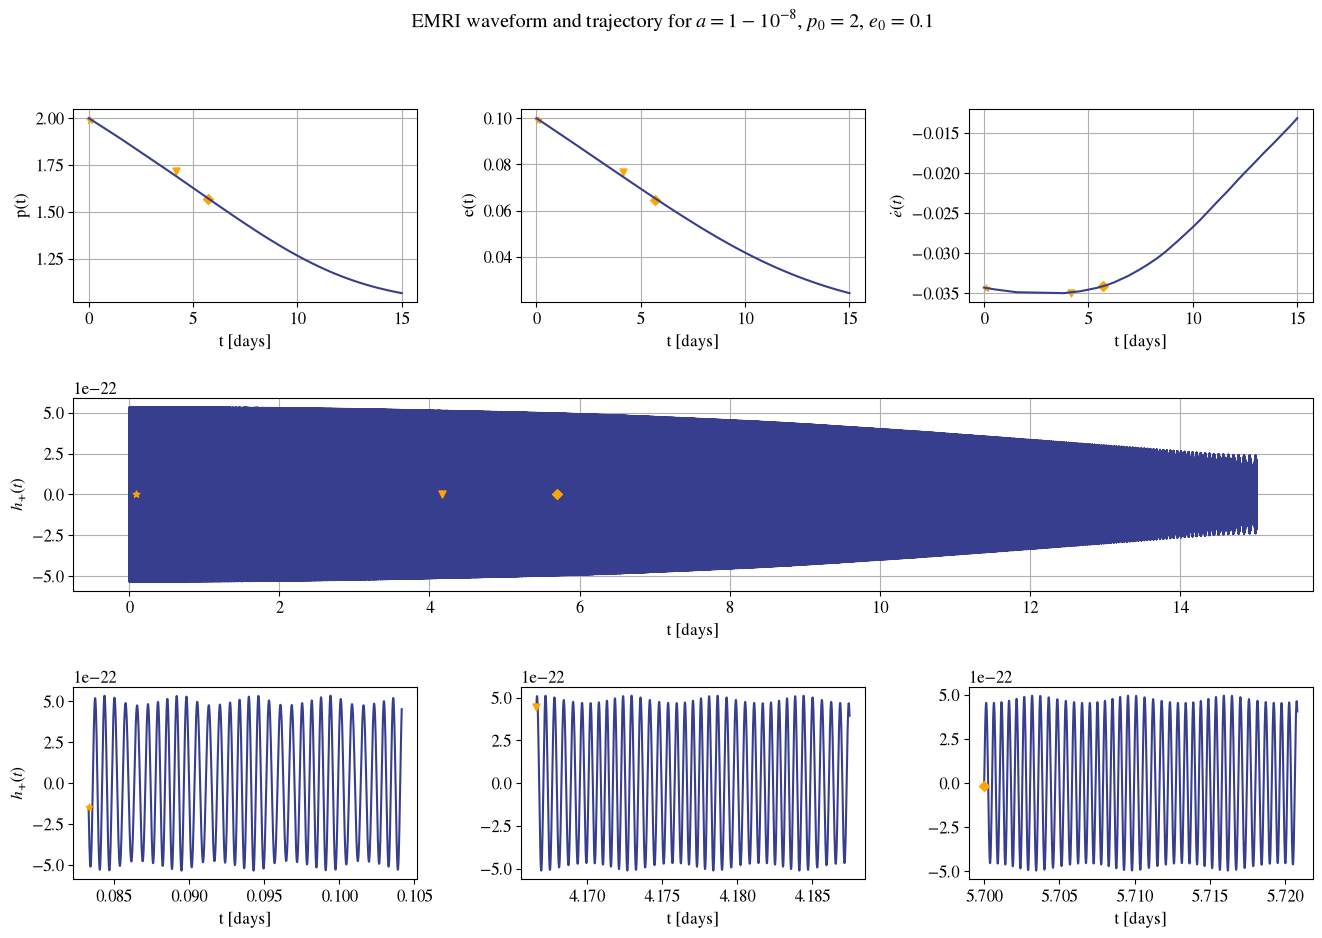

In [46]:
plt.rcParams['lines.color'] = 'black'

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, width_ratios=[1, 1, 1])

hour = 3600
day= 24*3600

ax_wf = fig.add_subplot(gs[1, :])

ax_p , ax_e= fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
ax_p.grid()
ax_e.grid() 


ax_snap0, ax_snap1, ax_snap2 , ax_dots = fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]), fig.add_subplot(gs[2, 2]),fig.add_subplot(gs[0, 2])

ax_p.plot(t_insp/(day), p_insp)
ax_p.set_xlabel("t [days]")
ax_p.set_ylabel("p(t)")

ax_e.plot(t_insp/(day), e_insp)
ax_e.set_xlabel("t [days]")
ax_e.set_ylabel("e(t)")

ax_wf.plot(t_wf/(day), wf[0])
ax_wf.set_xlabel("t [days]")
ax_wf.set_ylabel(r"$h_{+}(t)$")
ax_wf.grid()

ax_dots.plot(t_insp/(day), edots)
ax_dots.set_xlabel("t [days]")
ax_dots.set_ylabel(r"$\dot{e}(t)$")
ax_dots.grid()


tsnap0 = 2*hour
tsnap1 = 100*hour
tsnap2 =int(136.8*hour)

tsnaps = [tsnap0, tsnap1, tsnap2]
markers = ['*', 'v', 'D']
    
for  tsnap, marker, ax_snap in zip(tsnaps, markers, [ax_snap0, ax_snap1, ax_snap2]):
    p_arg = np.argmin(np.abs(t_insp - tsnap))

    ax_p.scatter(tsnap/day, p_insp[p_arg],s=25, color='orange', marker=marker,zorder=1)
    ax_e.scatter(tsnap/day, e_insp[p_arg],s=25, color='orange', marker=marker,zorder=1)
    ax_dots.scatter(tsnap/day, edots[p_arg],s=25, color='orange', marker=marker,zorder=1)
    ax_wf.scatter(tsnap/day, [0], s=25, color='orange', marker=marker,zorder=10)

    ax_snap.scatter(tsnap/day, wf[0][tsnap], s=25, color='orange', marker=marker,zorder=10)


snap_length = 0.5*hour
snap_length = int(snap_length)


ax_snap0.plot(t_wf[tsnap0:tsnap0+snap_length]/(day), wf[0][tsnap0:tsnap0+snap_length])
ax_snap0.set_xlabel("t [days]")
ax_snap0.set_ylabel(r"$h_{+}(t)$")

ax_snap1.plot(t_wf[tsnap1:tsnap1+snap_length]/(day), wf[0][tsnap1:tsnap1+snap_length])
ax_snap1.set_xlabel("t [days]")

ax_snap2.plot(t_wf[tsnap2:tsnap2 + snap_length]/(day), wf[0][tsnap2:tsnap2  + snap_length])
ax_snap2.set_xlabel("t [days]")

plt.subplots_adjust(hspace=0.5)
plt.subplots_adjust(wspace=0.3)

plt.suptitle(rf"EMRI waveform and trajectory for $a=1-10^{{-{n}}}$, $p_0$ = {round(p0,4)}, $e_0$ = {e0}")
#fig.savefig(f"EMRI_Traj_WF_n={n}_p0={p0}_e0={e0}_Full_grid.png", dpi=300, bbox_inches="tight")

In [ ]:
wf[:6]

In [ ]:
traj_pars = [1e6, 10, 1-10**(-5), 5, 0.2, 1]
traj_pars2 = [1e6, 10, 1-10**(-5), 8, 0.2, 1]
T=2

t1, p1, e1, xI1, Phi_phi1, Phi_theta1, Phi_r1 = traj_module(*traj_pars, T=T)
t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = traj_module(*traj_pars2, T=T)